In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

# 데이터 불러오기
df = pd.read_csv('merged_data.csv')

In [ ]:
# ==========================================
# 1단계: 데이터 기본 구조 & 결측치 확인
# ==========================================
print("=== 1단계: 데이터 기본 구조 ===")
print(f"전체 데이터 Shape: {df.shape}")
print(f"총 배치(Batch) 개수: {df['Batch_ID'].nunique()}개")

# 결측치 발생 컬럼 확인
missing_info = df.isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)

print("\n[결측치 발생 컬럼 목록]")
print(missing_info)

# 기초 통계량
print("\n[주요 변수 기초 통계량]")
target_cols = [
    'Penicillin concentration(P:g/L)', 
    'Dissolved oxygen concentration(DO2:mg/L)', 
    'Temperature(T:K)', 
    'pH(pH:pH)'
]
print(df[target_cols].describe())

=== 1단계: 데이터 기본 구조 ===
전체 데이터 Shape: (113935, 40)
총 배치(Batch) 개수: 100개

[결측치 발생 컬럼 목록]
PAA concentration offline(PAA_offline:PAA (g L^{-1}))      111873
NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))    111873
Offline Penicillin concentration(P_offline:P(g L^{-1}))    111873
Offline Biomass concentratio(X_offline:X(g L^{-1}))        111873
Viscosity(Viscosity_offline:centPoise)                     111873
dtype: int64

[주요 변수 기초 통계량]
       Penicillin concentration(P:g/L)  \
count                     1.139350e+05   
mean                      1.433395e+01   
std                       9.932453e+00   
min                       3.694700e-26   
25%                       5.531250e+00   
50%                       1.438000e+01   
75%                       2.268750e+01   
max                       3.618300e+01   

       Dissolved oxygen concentration(DO2:mg/L)  Temperature(T:K)  \
count                             113935.000000     113935.000000   
mean                                 

### 1️⃣ 데이터 기본 구조 및 결측치 탐색
* **데이터 규모**: 총 113,935개 행(Row)과 40개 열(Column)로 구성되며, 100개의 배치(`Batch_ID`) 데이터 포함
* **결측치 특징**: 
  * 전체 40개 변수 중 **5개 오프라인 측정 변수**(`PAA_offline`, `NH3_offline`, `P_offline`, `X_offline`, `Viscosity_offline`)에서만 결측치(111,873개, 약 98.2%)가 수집됨
  * **나머지 35개 실시간 센서 변수들**(온도, pH, DO, 농도 등)은 결측치가 0개로 완전하게 수집된 데이터

1. 기본 구조 & 결측치 확인

=== 2단계: 배치별 최종 생산량(P) 분포 탐색 ===

[배치별 최종 페니실린 농도(P) 요약 통계량]
count    100.000000
mean      24.011188
std        8.614545
min        3.157500
25%       17.342750
50%       27.275000
75%       30.822750
max       36.163000
Name: final_P, dtype: float64


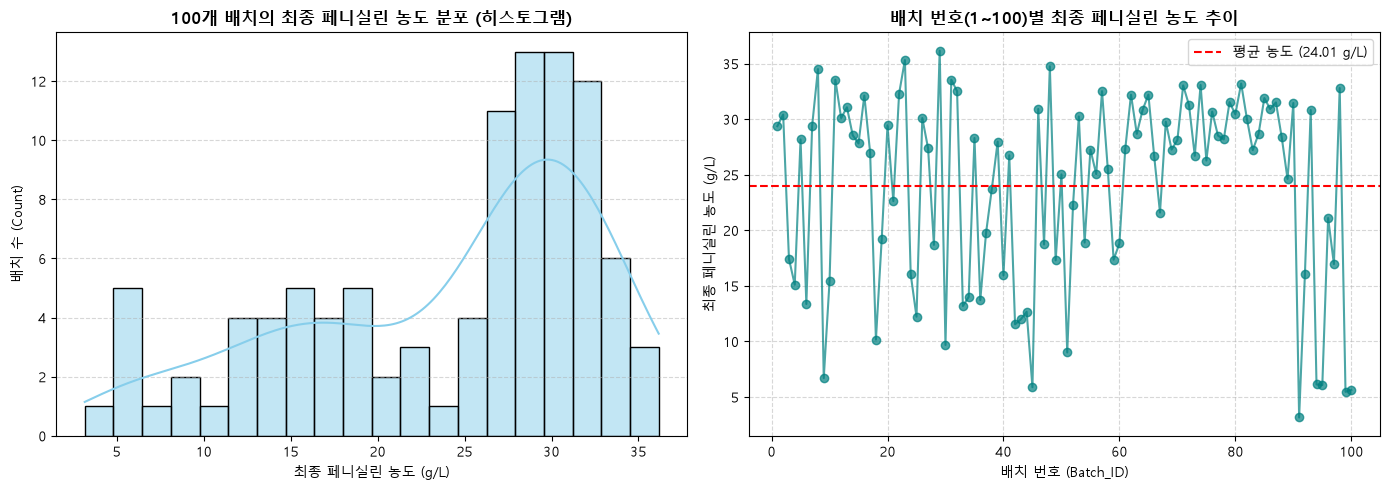

In [10]:
# ==========================================
# 2단계: 배치별 최종 생산량 분포 및 이상 패턴 탐색 (Pure Data)
# ==========================================
print("=== 2단계: 배치별 최종 생산량(P) 분포 탐색 ===")

# 배치(Batch_ID)별 마지막 시점의 생산량 요약
batch_end = df.groupby('Batch_ID').agg(
    max_time=('Time (h)', 'max'),
    final_P=('Penicillin concentration(P:g/L)', 'last'),
    total_yield=('Penicllin_yield_total (kg)', 'last')
).reset_index()

# 최종 페니실린 농도 기초 통계량
print("\n[배치별 최종 페니실린 농도(P) 요약 통계량]")
print(batch_end['final_P'].describe())

# 시각화: 100개 배치의 최종 생산량 히스토그램 & 개별 배치 흐름
plt.figure(figsize=(14, 5))

# 1) 히스토그램 & KDE (농도 분포 형태)
plt.subplot(1, 2, 1)
sns.histplot(batch_end['final_P'], kde=True, bins=20, color='skyblue')
plt.title('100개 배치의 최종 페니실린 농도 분포 (히스토그램)', fontsize=12, fontweight='bold')
plt.xlabel('최종 페니실린 농도 (g/L)', fontsize=10)
plt.ylabel('배치 수 (Count)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 2) 배치 번호(1~100)에 따른 최종 농도 추이 (이상치 탐지용)
plt.subplot(1, 2, 2)
plt.plot(batch_end['Batch_ID'], batch_end['final_P'], marker='o', linestyle='-', color='teal', alpha=0.7)
plt.axhline(y=batch_end['final_P'].mean(), color='red', linestyle='--', label=f'평균 농도 ({batch_end["final_P"].mean():.2f} g/L)')
plt.title('배치 번호(1~100)별 최종 페니실린 농도 추이', fontsize=12, fontweight='bold')
plt.xlabel('배치 번호 (Batch_ID)', fontsize=10)
plt.ylabel('최종 페니실린 농도 (g/L)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2️⃣ 배치별 최종 생산량(P) 분포 탐색
* **생산량 요약**: 전체 100개 배치의 평균 최종 농도는 **24.01 g/L** (최소 3.16 g/L ~ 최대 36.16 g/L)로 나타남
* **다봉형(Bimodal) 분포 특성**: 
  * 히스토그램 확인 결과, **27~33 g/L 부근**에 가장 많은 배치(고수율 그룹)가 밀집해 있음
  * 반면 **5~20 g/L 사이**에도 넓게 배치가 분포하여 공정 조건에 따른 생산성 격차가 매우 큼
* **배치 번호별 변동성 추이**: 
  * 배치 번호(1~100) 전체에 걸쳐 페니실린 농도가 평균 이하로 급감하는 배치들이 주기적으로 관측됨 (이상 배치 및 저성능 운전 조건 존재)
  * 특정 구역에 상관없이 생산량의 널뛰기(변동폭)가 커서 **공정 조건 안정화**가 핵심 주제가 될 수 있음을 암시함

=== 3단계: 시간(Time)에 따른 주요 변수 시계열 흐름 ===
선택된 바이오매스 컬럼명: Offline Biomass concentratio(X_offline:X(g L^{-1}))


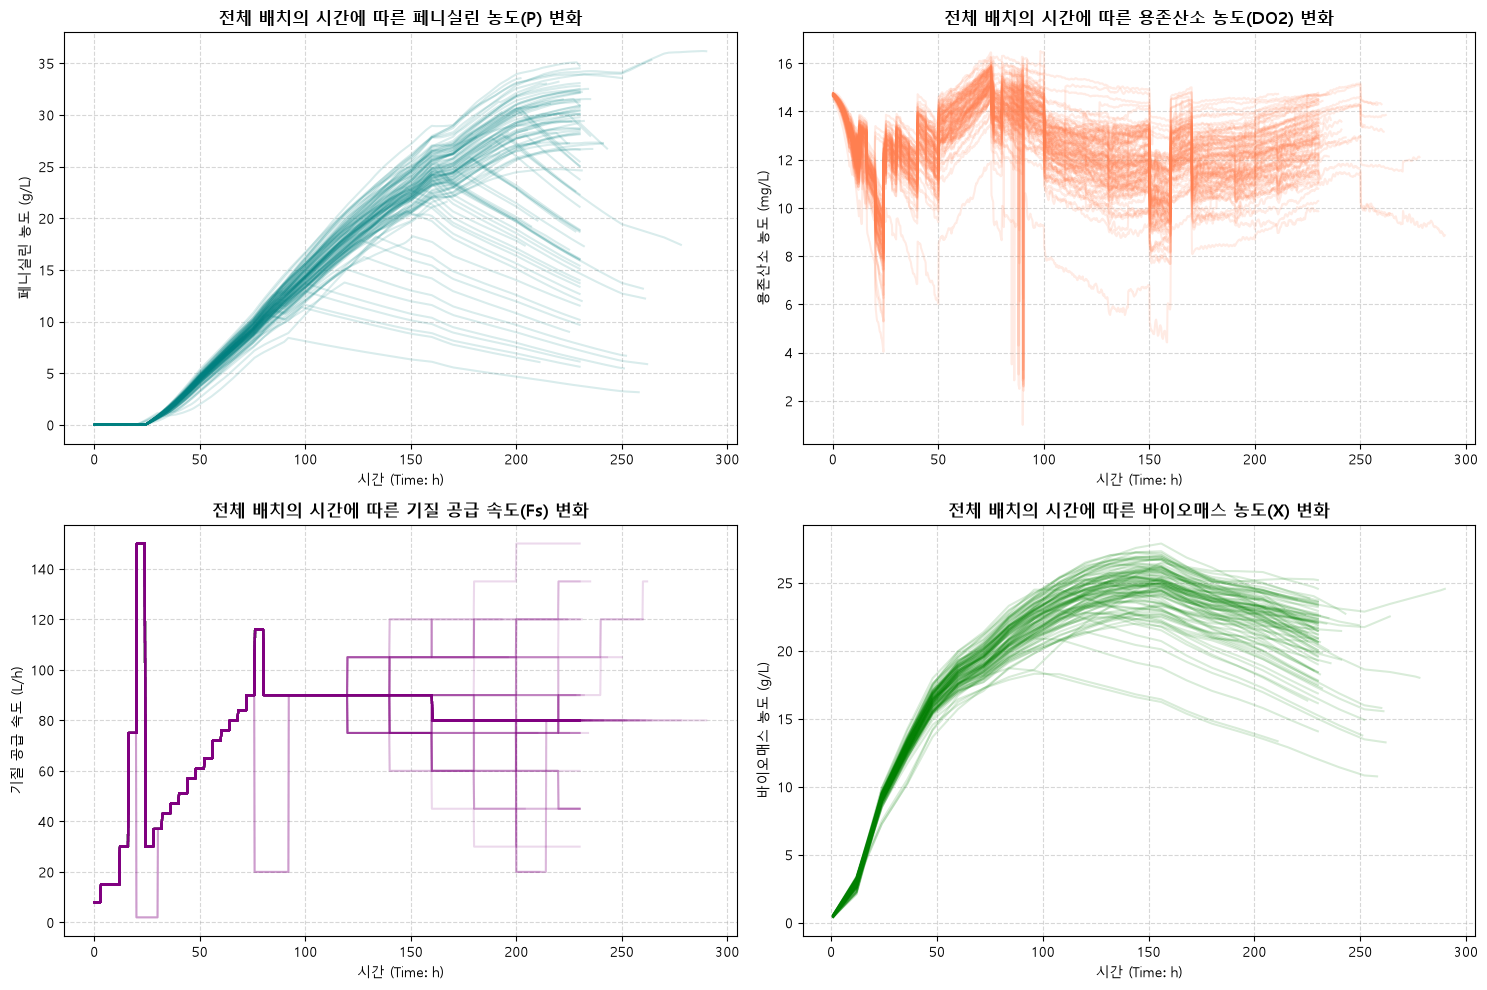

In [14]:
# ==========================================
# 3단계: 시간(Time)에 따른 주요 변수 시계열 흐름 
# ==========================================
print("=== 3단계: 시간(Time)에 따른 주요 변수 시계열 흐름 ===")

# 바이오매스 관련 컬럼 안전하게 탐색 (Biomass 단어 포함 컬럼 찾기)
biomass_cols = [col for col in df.columns if 'Biomass' in col or 'X(' in col or 'X_' in col]

# 온라인 바이오매스 컬럼 지정 (없을 경우 예외 처리)
if biomass_cols:
    x_col = biomass_cols[0]
else:
    # 혹시 단어가 완전히 다를 경우를 대비한 기본값
    x_col = df.columns[3] 

print(f"선택된 바이오매스 컬럼명: {x_col}")

plt.figure(figsize=(15, 10))

# 1) 시간에 따른 페니실린 농도(P) 전체 배치 궤적
plt.subplot(2, 2, 1)
sns.lineplot(data=df, x='Time (h)', y='Penicillin concentration(P:g/L)', units='Batch_ID', estimator=None, color='teal', alpha=0.15)
plt.title('전체 배치의 시간에 따른 페니실린 농도(P) 변화', fontsize=12, fontweight='bold')
plt.xlabel('시간 (Time: h)')
plt.ylabel('페니실린 농도 (g/L)')
plt.grid(True, linestyle='--', alpha=0.5)

# 2) 시간에 따른 용존산소 농도(DO2) 전체 배치 궤적
plt.subplot(2, 2, 2)
sns.lineplot(data=df, x='Time (h)', y='Dissolved oxygen concentration(DO2:mg/L)', units='Batch_ID', estimator=None, color='coral', alpha=0.15)
plt.title('전체 배치의 시간에 따른 용존산소 농도(DO2) 변화', fontsize=12, fontweight='bold')
plt.xlabel('시간 (Time: h)')
plt.ylabel('용존산소 농도 (mg/L)')
plt.grid(True, linestyle='--', alpha=0.5)

# 3) 시간에 따른 기질 공급 속도(Fs) 전체 배치 궤적
plt.subplot(2, 2, 3)
sns.lineplot(data=df, x='Time (h)', y='Sugar feed rate(Fs:L/h)', units='Batch_ID', estimator=None, color='purple', alpha=0.15)
plt.title('전체 배치의 시간에 따른 기질 공급 속도(Fs) 변화', fontsize=12, fontweight='bold')
plt.xlabel('시간 (Time: h)')
plt.ylabel('기질 공급 속도 (L/h)')
plt.grid(True, linestyle='--', alpha=0.5)

# 4) 시간에 따른 바이오매스 농도(X) 전체 배치 궤적
plt.subplot(2, 2, 4)
sns.lineplot(data=df, x='Time (h)', y=x_col, units='Batch_ID', estimator=None, color='green', alpha=0.15)
plt.title('전체 배치의 시간에 따른 바이오매스 농도(X) 변화', fontsize=12, fontweight='bold')
plt.xlabel('시간 (Time: h)')
plt.ylabel('바이오매스 농도 (g/L)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3️⃣ 시간에 따른 주요 공정 변수 시계열 패턴 탐색 (Pure Data)
* **생산물(P) 생성 궤적**: 약 25시간 이후부터 페니실린 농도가 급격히 상승하며, 대다수 정상 배치는 200시간 전후로 30 g/L 이상에 도달함. 그러나 일부 저수율 배치는 초기/중반부터 성장이 저조하여 상단 궤적에서 완전히 이탈함.
* **용존산소(DO2) 변동성**: 배양 중반(50~100시간) 부근에서 용존산소가 급격히 감소하거나 강하게 변동함. 이는 균주의 왕성한 호흡 및 기질 투입 속도 변화와 밀접한 연관이 있음.
* **기질 공급 속도(Fs) 패턴 차이**: 기질(설탕) 공급 스케줄이 배치마다 상당한 차이를 보임. 계단식 상승, 일정 유지, 잦은 변동 등 기질 제어 패턴의 차이가 최종 페니실린 생산성 격차를 결정짓는 요인임을 암시함.
* **바이오매스(X) 증식 패턴**: 초반~150시간까지는 균체 농도가 일정하게 증가하다가 이후 정체 및 감소하는 전형적인 배양 곡선을 보임. 하단으로 이탈하는 저성능 배치는 바이오매스 증식부터 정상 배치보다 낮게 유지됨.

=== 4단계: 주요 공정 변수 상관관계 분석 ===


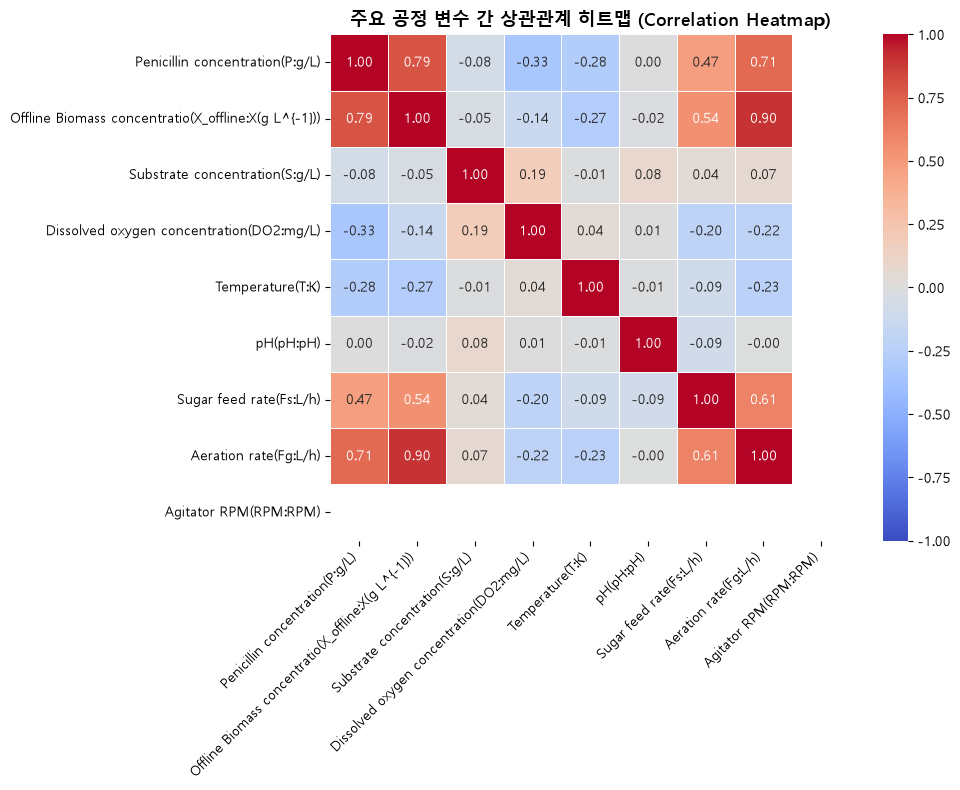


[페니실린 농도(P)와의 상관계수 Top/Bottom]
Penicillin concentration(P:g/L)                        1.000000
Offline Biomass concentratio(X_offline:X(g L^{-1}))    0.794359
Aeration rate(Fg:L/h)                                  0.711345
Sugar feed rate(Fs:L/h)                                0.469741
pH(pH:pH)                                              0.003703
Substrate concentration(S:g/L)                        -0.077792
Temperature(T:K)                                      -0.279469
Dissolved oxygen concentration(DO2:mg/L)              -0.329568
Agitator RPM(RPM:RPM)                                       NaN
Name: Penicillin concentration(P:g/L), dtype: float64


In [15]:
# ==========================================
# 4단계: 주요 공정 변수 간 상관관계 분석 (Heatmap)
# ==========================================
print("=== 4단계: 주요 공정 변수 상관관계 분석 ===")

# 상관관계 분석에 사용할 주요 실시간 센서 변수들 선정
corr_cols = [
    'Penicillin concentration(P:g/L)',
    x_col,  # 바이오매스 농도
    'Substrate concentration(S:g/L)',
    'Dissolved oxygen concentration(DO2:mg/L)',
    'Temperature(T:K)',
    'pH(pH:pH)',
    'Sugar feed rate(Fs:L/h)',
    'Aeration rate(Fg:L/h)',
    'Agitator RPM(RPM:RPM)'
]

# 실제 존재하는 컬럼만 필터링
corr_cols = [col for col in corr_cols if col in df.columns]

# 상관계수 행렬 계산
corr_matrix = df[corr_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('주요 공정 변수 간 상관관계 히트맵 (Correlation Heatmap)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 페니실린 농도(P)와 다른 변수 간의 상관계수만 출력
print("\n[페니실린 농도(P)와의 상관계수 Top/Bottom]")
print(corr_matrix['Penicillin concentration(P:g/L)'].sort_values(ascending=False))

### 4️⃣ 주요 공정 변수 간 상관관계 분석 (Heatmap)
* **강한 양의 상관관계**:
  * **바이오매스 농도(X_offline, 0.79)** 및 **공기 주입 속도(Fg, 0.71)**가 페니실린 생산량(P)과 매우 높은 양의 상관관계를 보임. 균체가 충분히 증식하고 산소 공급(Aeration)이 원활할수록 최종 생산량이 높아짐을 의미함.
  * **기질 공급 속도(Fs, 0.47)** 역시 생산량 증가에 긍정적인 영향을 미침.
* **음의 상관관계 및 제어 필요 변수**:
  * **용존산소(DO2, -0.33)** 및 **온도(T, -0.28)**는 페니실린 농도와 음의 상관관계를 보임. 이는 배양 후반부로 갈수록 페니실린이 축적되는 반면, 균주의 왕성한 호흡으로 DO가 감소하는 공정 특성이 반영된 결과임.
* **독립적 변수**:
  * **pH(0.00)**는 전체 데이터 기준 생산량과의 단일 상관계수가 0에 가깝지만, 이는 정상 범주 내에서 일정하게 제어되고 있기 때문일 수 있어 시계열 변동폭 제어 관점에서 추가 확인이 필요함.

=== 5단계: 프로젝트 기획서용 최종 종합 요약 ===

[상위 10개 고수율 배치 주요 평균값]
최종_페니실린농도_gL     33.997100
생산성(g/L/h)        0.145168
평균_용존산소_mgL      12.043742
평균_온도_K         298.018537
평균_pH             6.493413
dtype: float64

[하위 10개 저수율 배치 주요 평균값]
최종_페니실린농도_gL      6.788980
생산성(g/L/h)        0.028928
평균_용존산소_mgL      13.482597
평균_온도_K         298.058957
평균_pH             6.508047
dtype: float64


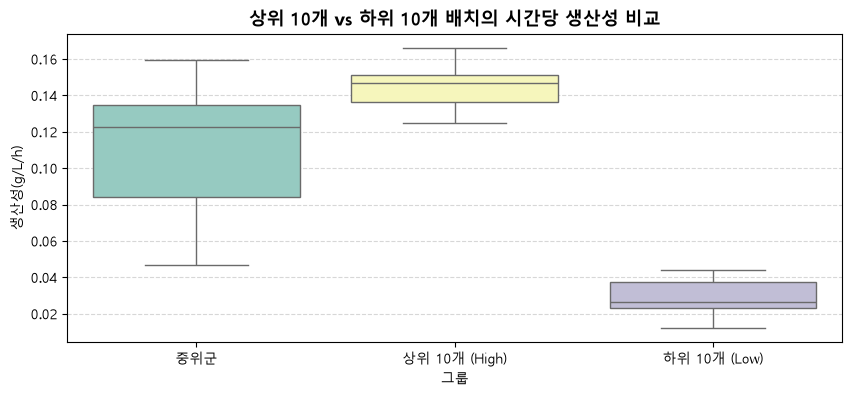

In [16]:
# ==========================================
# 5단계: EDA 결과 종합 및 기획서용 인사이트 요약
# ==========================================
print("=== 5단계: 프로젝트 기획서용 최종 종합 요약 ===")

# 1. 배치별 핵심 성과 지표(KPI) 종합 테이블 생성
batch_final = df.groupby('Batch_ID').agg(
    Strategy=('Strategy', 'first') if 'Strategy' in df.columns else ('Batch_ID', lambda x: 'Unknown'),
    최대운전시간_h=('Time (h)', 'max'),
    최종_페니실린농도_gL=('Penicillin concentration(P:g/L)', 'last'),
    최종_기질농도_gL=('Substrate concentration(S:g/L)', 'last'),
    평균_용존산소_mgL=('Dissolved oxygen concentration(DO2:mg/L)', 'mean'),
    평균_온도_K=('Temperature(T:K)', 'mean'),
    평균_pH=('pH(pH:pH)', 'mean')
).reset_index()

# 생산성 파생변수 추가 (시간당 생산량)
batch_final['생산성(g/L/h)'] = batch_final['최종_페니실린농도_gL'] / batch_final['최대운전시간_h']

# 2. 상위 10개 고수율 배치 vs 하위 10개 저수율 배치 특징 비교
top_10 = batch_final.nlargest(10, '최종_페니실린농도_gL')
bottom_10 = batch_final.nsmallest(10, '최종_페니실린농도_gL')

print("\n[상위 10개 고수율 배치 주요 평균값]")
print(top_10[['최종_페니실린농도_gL', '생산성(g/L/h)', '평균_용존산소_mgL', '평균_온도_K', '평균_pH']].mean())

print("\n[하위 10개 저수율 배치 주요 평균값]")
print(bottom_10[['최종_페니실린농도_gL', '생산성(g/L/h)', '평균_용존산소_mgL', '평균_온도_K', '평균_pH']].mean())

# 3. 고수율 vs 저수율 비교 박스플롯 시각화
batch_final['그룹'] = '중위군'
batch_final.loc[batch_final['Batch_ID'].isin(top_10['Batch_ID']), '그룹'] = '상위 10개 (High)'
batch_final.loc[batch_final['Batch_ID'].isin(bottom_10['Batch_ID']), '그룹'] = '하위 10개 (Low)'

plt.figure(figsize=(10, 4))
sns.boxplot(data=batch_final, x='그룹', y='생산성(g/L/h)', palette='Set3', hue='그룹', legend=False)
plt.title('상위 10개 vs 하위 10개 배치의 시간당 생산성 비교', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 5️⃣ 상위 vs 하위 배치 성과 비교 및 종합 인사이트
* **생산성 격차**:
  * 상위 10개 고수율 배치의 평균 생산성은 **0.145 g/L/h** (최종 농도 ~34.0 g/L)인 반면, 하위 10개 저수율 배치는 **0.029 g/L/h** (최종 농도 ~6.8 g/L)로 **약 5배 이상의 극심한 성과 격차**가 발생함.
* **공정 변수별 비교 특성**:
  * **온도(T) 및 pH**: 상위군(298.02 K, pH 6.49)과 하위군(298.06 K, pH 6.51) 간의 평균값 차이가 미미함. (단순 평균보다는 시간대별 제어 세밀함이 수율을 결정할 가능성 높음)
  * **용존산소(DO2)**: 상위군(12.04 mg/L)이 하위군(13.48 mg/L)보다 오히려 평균 용존산소가 낮게 나옴. 이는 고수율 배치일수록 균체 증식과 페니실린 합성이 왕성하게 일어나 산소 소비량이 많았기 때문으로 해석됨.